# Value-sequence recurrence prediction — Acrobot

Same experiment as `experiments/dqn_cartpole/exp1_recurrence.ipynb` on the
env where the value signal actually *moves* (ramps from ~-75 toward 0 as the
swing-up progresses), making it the real test of the order-r recurrence claim.
See `docs/value_recurrence_prediction.md`.


In [1]:
import pathlib
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, str(pathlib.Path.cwd().parents[1] / "src"))
from experiment import load_config, build_env, build_agent, train
from agents.hankel_dqn_agent import HankelDQNAgent
from analysis.low_rank.recurrence import fit_ar, free_run, nrmse, predict_one_step

VARIANTS = {"baseline": dict(hankel_weight=0.0)}
N_TRAJ, N_TRAIN, TRAJ_SEED0, BURN = 40, 20, 40_000, 8
ORDERS = [1, 2, 3, 4, 8]
HORIZONS = [1, 2, 4, 8, 16, 32, 64]
RESULTS = pathlib.Path("results_recurrence")
RESULTS.mkdir(exist_ok=True)


class QNetwork(torch.nn.Module):
    def __init__(self, in_dim, out_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [torch.nn.Linear(last, h), torch.nn.ReLU()]
            last = h
        layers.append(torch.nn.Linear(last, out_dim))
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


## Train (cached) and collect 40 greedy trajectories per variant

In [2]:
def greedy_trajectory(agent, env, seed):
    qs, rews, acts = [], [], []
    state, _ = env.reset(seed=seed)
    terminated = truncated = False
    while not (terminated or truncated):
        with torch.no_grad():
            t = torch.as_tensor(state, dtype=torch.float32, device=agent.device).unsqueeze(0)
            q = agent.policy_net(t).squeeze(0).cpu().numpy()
        a = int(q.argmax())
        qs.append(q); acts.append(a)
        state, reward, terminated, truncated, _ = env.step(a)
        rews.append(reward)
    return np.array(qs, float), np.array(rews, float), np.array(acts)


def train_and_collect(variant, overrides, seed=0):
    out = RESULTS / f"{variant}_s{seed}.npz"
    if out.exists():
        return
    cfg = load_config("config_hankel.yaml")
    cfg["experiment"]["seed"] = seed
    cfg["agent"].update(overrides)
    cfg["analysis"] = {"ep_freq": 10 ** 9, "methods": []}
    torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
    env = build_env(cfg)
    nn_extra = {"in_dim": env.observation_space.shape[0], "out_dim": env.action_space.n,
                "hidden_sizes": cfg["network"]["hidden_sizes"]}
    agent = build_agent(cfg, env, q_network=QNetwork, nn_extra_kwargs=nn_extra,
                        agent_cls=HankelDQNAgent)
    rewards = train(cfg, agent, env)
    agent.epsilon = 0.0
    agent.policy_net.eval()
    data = {"gamma": np.float64(cfg["agent"]["discount_factor"]),
            "train_rewards": np.array(rewards, float)}
    for i in range(N_TRAJ):
        q, r, a = greedy_trajectory(agent, env, TRAJ_SEED0 + i)
        data[f"ep{i}_q"], data[f"ep{i}_r"], data[f"ep{i}_a"] = q, r, a
    np.savez(out, **data)
    torch.save(agent.policy_net.state_dict(), RESULTS / f"{variant}_s{seed}.pt")
    env.close()


for _v, _o in VARIANTS.items():
    train_and_collect(_v, _o)


def load_variant(variant, seed=0):
    d = np.load(RESULTS / f"{variant}_s{seed}.npz")
    gamma = float(d["gamma"])
    vs, rets = [], []
    for i in range(N_TRAJ):
        q, r, a = d[f"ep{i}_q"], d[f"ep{i}_r"], d[f"ep{i}_a"]
        v = q[np.arange(len(a)), a]
        g, acc = np.zeros(len(r)), 0.0
        for t in range(len(r) - 1, -1, -1):
            acc = r[t] + gamma * acc
            g[t] = acc
        vs.append(v); rets.append(g)
    return vs, rets, gamma


DATA = {v: load_variant(v) for v in VARIANTS}
for v, (vs, _, g) in DATA.items():
    print(f"{v}: {len(vs)} greedy trajectories, mean length "
          f"{np.mean([len(s) for s in vs]):.0f}, gamma {g}")


baseline: 40 greedy trajectories, mean length 90, gamma 0.99


## The value signal along held-out trajectories

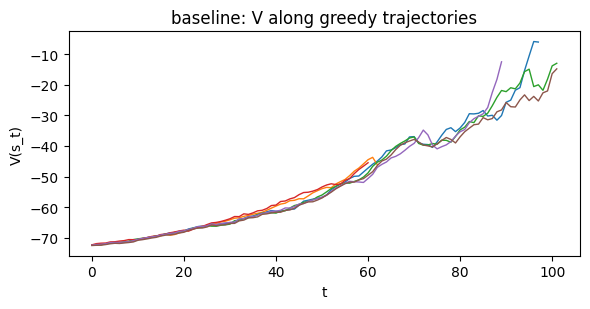

In [3]:
fig, axes = plt.subplots(1, len(DATA), figsize=(6 * len(DATA), 3.2), squeeze=False)
for ax, (variant, (vs, _, _g)) in zip(axes[0], DATA.items()):
    for v in vs[N_TRAIN:N_TRAIN + 6]:
        ax.plot(v, lw=1)
    ax.set(title=f"{variant}: V along greedy trajectories", xlabel="t", ylabel="V(s_t)")
plt.tight_layout(); plt.show()


## A. Global AR(r) fit on 20 trajectories, one-step-ahead error on 20 held-out

`persistence` predicts the previous value; beating it means the recurrence captures real temporal structure, not just smoothness.

In [4]:
for variant, (vs, _, _g) in DATA.items():
    tr, te = vs[:N_TRAIN], vs[N_TRAIN:]
    pers = np.mean([nrmse(v[:-1], v[1:]) for v in te])
    print(f"{variant}: one-step nRMSE on {len(te)} held-out trajs — persistence {pers:.4f}")
    for r in ORDERS:
        c = fit_ar(tr, r)
        e = np.mean([nrmse(predict_one_step(c, v), v[r:]) for v in te])
        print(f"  AR(r={r}): {e:.4f}   coeffs {np.round(c, 4)}")


baseline: one-step nRMSE on 20 held-out trajs — persistence 0.0201
  AR(r=1): 0.0183   coeffs [0.9909]
  AR(r=2): 0.0173   coeffs [ 1.198  -0.2054]
  AR(r=3): 0.0172   coeffs [ 1.1538  0.0543 -0.2143]
  AR(r=4): 0.0174   coeffs [ 1.1338  0.0352  0.0045 -0.1788]
  AR(r=8): 0.0181   coeffs [ 1.0755  0.0575  0.0083 -0.1717  0.0976  0.1564 -0.025  -0.2017]


## B. Free-run: recursive extrapolation from r seed values

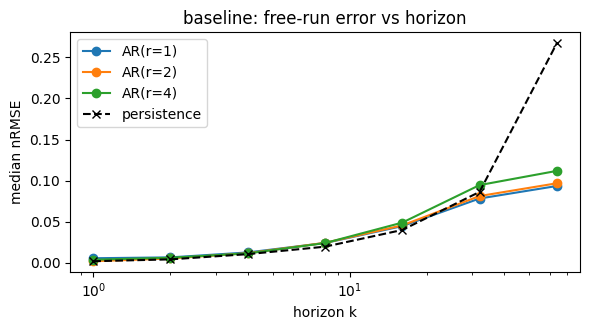

In [5]:
fig, axes = plt.subplots(1, len(DATA), figsize=(6 * len(DATA), 3.4), squeeze=False)
for ax, (variant, (vs, _, _g)) in zip(axes[0], DATA.items()):
    tr, te = vs[:N_TRAIN], vs[N_TRAIN:]
    for r in [1, 2, 4]:
        c = fit_ar(tr, r)
        med = [np.median([nrmse(free_run(c, v[BURN:BURN + r], k), v[BURN + r:BURN + r + k])
                          for v in te if len(v) >= BURN + r + k]) for k in HORIZONS]
        ax.plot(HORIZONS, med, marker="o", label=f"AR(r={r})")
    med_p = [np.median([nrmse(np.full(k, v[BURN - 1]), v[BURN:BURN + k])
                        for v in te if len(v) >= BURN + k]) for k in HORIZONS]
    ax.plot(HORIZONS, med_p, marker="x", ls="--", color="k", label="persistence")
    ax.set(title=f"{variant}: free-run error vs horizon", xlabel="horizon k",
           ylabel="median nRMSE", xscale="log")
    ax.legend()
plt.tight_layout(); plt.show()


### Example forecasts (first variant, AR(2), 2 seed values)

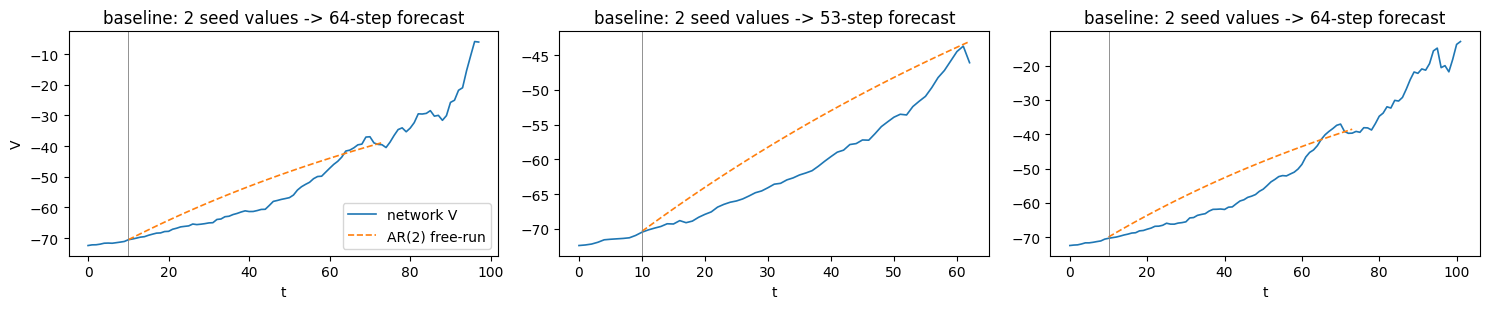

In [6]:
variant = list(DATA)[0]
vs, _, _g = DATA[variant]
c2 = fit_ar(vs[:N_TRAIN], 2)
fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
for ax, v in zip(axes, vs[N_TRAIN:N_TRAIN + 3]):
    k = min(len(v) - BURN - 2, 64)
    ax.plot(range(len(v)), v, lw=1.2, label="network V")
    ax.plot(range(BURN + 2, BURN + 2 + k), free_run(c2, v[BURN:BURN + 2], k),
            lw=1.2, ls="--", label="AR(2) free-run")
    ax.axvline(BURN + 2, color="grey", lw=0.6)
    ax.set(xlabel="t", title=f"{variant}: 2 seed values -> {k}-step forecast")
axes[0].set_ylabel("V"); axes[0].legend()
plt.tight_layout(); plt.show()


## C. Against the *true* discounted return-to-go

The use case: can extrapolated values stand in for critic evaluations (PG baselines, truncated-rollout completion)?

In [7]:
for variant, (vs, rets, gamma) in DATA.items():
    te, te_g = vs[N_TRAIN:], rets[N_TRAIN:]
    c = fit_ar(vs[:N_TRAIN], 2)
    crit, extr, true = [], [], []
    for v, g in zip(te, te_g):
        end = min(len(v), BURN + 2 + 64)
        if end <= BURN + 2:
            continue
        crit.extend(v[BURN + 2:end])
        extr.extend(free_run(c, v[BURN:BURN + 2], end - BURN - 2))
        true.extend(g[BURN + 2:end])
    crit, extr, true = map(np.asarray, (crit, extr, true))
    print(f"{variant}: vs true discounted return-to-go G_t (held-out)")
    print(f"  critic V(s_t):        nRMSE {nrmse(crit, true):.4f}  corr {np.corrcoef(crit, true)[0, 1]:.3f}")
    print(f"  AR(2) extrapolation:  nRMSE {nrmse(extr, true):.4f}  corr {np.corrcoef(extr, true)[0, 1]:.3f}")

    err_v, err_ar, err_none = [], [], []
    for v, g in zip(te, te_g):
        T = len(v) // 2
        if T <= 2:
            continue
        partial = g[0] - gamma ** T * g[T]
        err_v.append(abs(partial + gamma ** T * v[T] - g[0]))
        err_ar.append(abs(partial + gamma ** T * free_run(c, v[T - 2:T], 1)[0] - g[0]))
        err_none.append(abs(partial - g[0]))
    print(f"  truncated-return completion |G-hat - G_0|: network V(s_T) {np.mean(err_v):.3f}, "
          f"AR(2) v-hat_T {np.mean(err_ar):.3f}, no bootstrap {np.mean(err_none):.3f}")


baseline: vs true discounted return-to-go G_t (held-out)
  critic V(s_t):        nRMSE 0.6061  corr 0.776
  AR(2) extrapolation:  nRMSE 0.4981  corr 0.774
  truncated-return completion |G-hat - G_0|: network V(s_T) 15.552, AR(2) v-hat_T 15.600, no bootstrap 22.558


## Coefficient drift across training

Probes during training (every 25 `agent.train()` calls): freeze the policy, roll 8 greedy trajectories on fixed seeds, fit the global AR(2); produced by the drift_collect script, cached as `drift_<variant>_s0.npz`.

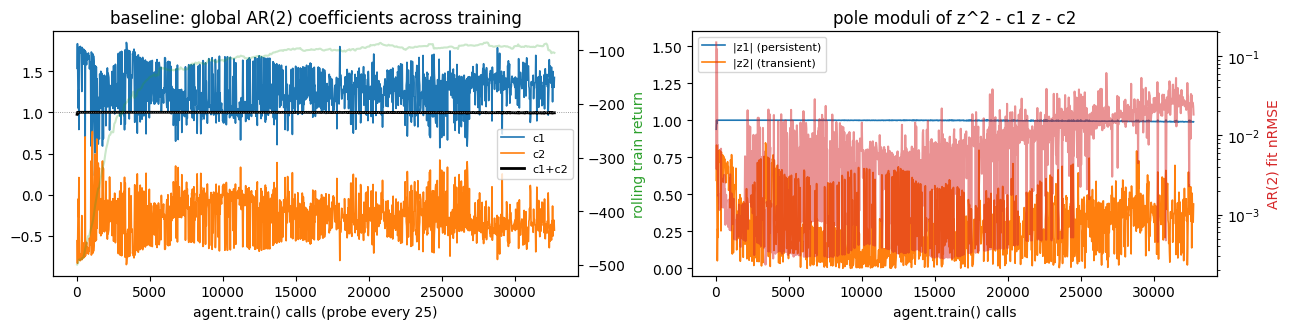

In [8]:
import numpy.polynomial.polynomial as npoly

drift = {v: np.load(RESULTS / f"drift_{v}_s0.npz") for v in VARIANTS
         if (RESULTS / f"drift_{v}_s0.npz").exists()}
fig, axes = plt.subplots(len(drift), 2, figsize=(13, 3.4 * len(drift)), squeeze=False)
for row, (variant, d) in zip(axes, drift.items()):
    x, c1, c2 = d["episode"], d["c1"], d["c2"]
    ax = row[0]
    ax.plot(x, c1, label="c1", lw=1.2)
    ax.plot(x, c2, label="c2", lw=1.2)
    ax.plot(x, c1 + c2, label="c1+c2", lw=2, color="k")
    ax.axhline(1.0, color="grey", lw=0.6, ls=":")
    ax.set(title=f"{variant}: global AR(2) coefficients across training",
           xlabel="agent.train() calls (probe every 25)")
    ax.legend(fontsize=8)
    tw = ax.twinx()
    rr = d["train_rewards"]
    roll = np.convolve(rr, np.ones(25) / 25, mode="valid")
    tw.plot(np.linspace(x[0], x[-1], len(roll)), roll, color="tab:green", alpha=0.25)
    tw.set_ylabel("rolling train return", color="tab:green")
    ax = row[1]
    mods = np.array([sorted(np.abs(npoly.polyroots([-b, -a, 1.0])))[::-1]
                     for a, b in zip(c1, c2)])
    ax.plot(x, mods[:, 0], label="|z1| (persistent)", lw=1.2)
    ax.plot(x, mods[:, 1], label="|z2| (transient)", lw=1.2)
    ax.set(title="pole moduli of z^2 - c1 z - c2", ylim=(-0.05, 1.6),
           xlabel="agent.train() calls")
    ax.legend(fontsize=8, loc="upper left")
    tw = ax.twinx()
    tw.semilogy(x, d["fit_nrmse"], color="tab:red", alpha=0.5)
    tw.set_ylabel("AR(2) fit nRMSE", color="tab:red")
plt.tight_layout(); plt.show()


## Findings (seed 0, 40 greedy trajectories)

- **A global AR(2) map, fitted on 20 trajectories, transfers to held-out
  trajectories**: one-step nRMSE 0.0173 vs 0.0201 persistence, and — the part
  that matters — free-run extrapolation stays at ~10% nRMSE 64 steps out
  (most of an episode) while persistence degrades to ~27%. The recurrence
  captures the *ramp dynamics*, not just smoothness. r = 2-3 is the sweet
  spot; r = 8 overfits, consistent with the measured Hankel rank.
- **Extrapolated values track the true return-to-go slightly better than the
  critic itself** (nRMSE 0.50 vs 0.61, corr ~0.77 both): the recurrence
  denoises the critic's step-to-step wobble.
- **Truncated-return completion**: bootstrap with the AR(2) forecast equals
  bootstrap with the network's own V(s_T) (15.6 vs 15.6, vs 22.6 without).
- Per-trajectory fits on a half-episode extrapolate poorly (nRMSE ~0.32) —
  the *global* (policy-level) map is the right object, single-trajectory
  prefixes are not enough data.
- **Coefficient drift:** same picture as CartPole — (c1, c2) drift widely
  across training while c1 + c2 hugs 1 (unit root present from the first
  probe); fit nRMSE collapses 0.148 -> ~0.02 as the policy converges. The
  recurrence *structure* is training-stable, its *coefficients* are not.
  (x-axis is agent.train() calls: this env trains mid-episode.)
- Caveat: one seed, converged greedy policy.
